## -1. Google Collab Set-up


In [ ]:
from google.colab import drive
import os

# 1. Mounting Google Drive: This allows Colab to access files in your Google Drive
drive.mount('/content/drive/')

# 2. Tell Colab where to find your assignment files and where to save your work

# TODO: Enter the relative path in your Google Drive of the assignment.
FOLDERNAME = "GeorgiaTech/DEEP/project" # e.g. 'cs7643/ps0/'

assert FOLDERNAME is not None, "[!] Enter the foldername."

FULL_PATH = "/content/drive/MyDrive/" + FOLDERNAME
assert os.path.exists(FULL_PATH), "Make sure your FOLDERNAME is correct"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
%cd $FULL_PATH

/content/drive/MyDrive/GeorgiaTech/DEEP/project




*italicized text*

## 0. Imports


In [ ]:
import os
print("Current directory:", os.getcwd())
print("Files here:", os.listdir())

Current directory: /content/drive/MyDrive/GeorgiaTech/DEEP/project
Files here: ['GARCH_Baseline.ipynb', 'dataloading', 'RNNmodel.py', 'README.md', 'start.py', 'train.py', 'test_data.py', 'data.pkl', 'main_analysis.ipynb']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from test_data import prepare_data, VolatilityDataset, TICKERS
from RNNmodel import VanillaRNN
from train import run_training, evaluate

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load Data

In [ ]:
returns, target_vol = prepare_data(force_download=False)

print('Returns shape:    ', returns.shape)    # (trading_days, num_stocks)
print('Target vol shape: ', target_vol.shape)
print('Date range:       ', returns.index[0], '→', returns.index[-1])

--- Data Pipeline ---


/content/drive/MyDrive/GeorgiaTech/DEEP/project/test_data.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, multi_level_index=False)
[*********************100%***********************]  99 of 99 completed


--- Data saved to stock_data.pkl ---
Returns shape:     (5283, 99)
Target vol shape:  (5283, 99)
Date range:        2000-01-03 00:00:00 → 2020-12-30 00:00:00


## 2. Chronological Train / Val / Test Splits


- **Train:** 2000–2017
- **Val:** 2018, starting at the 21st trading day (buffer for last training target window)
- **Test:** 2019–2020, starting at the 21st trading day of 2019

In [ ]:
# --- Slice DataFrames by date ---
train_returns = returns.loc[:'2017-12-31']
train_target  = target_vol.loc[:'2017-12-31']

# Val: all of 2018
val_returns = returns.loc['2018-01-01':'2018-12-31']
val_target  = target_vol.loc['2018-01-01':'2018-12-31']

# Test: 2019–2020 (same reasoning)
test_returns = returns.loc['2019-01-01':'2020-12-31']
test_target  = target_vol.loc['2019-01-01':'2020-12-31']

print(f'Train days: {len(train_returns)}  |  '
      f'Val days: {len(val_returns)}  |  '
      f'Test days: {len(test_returns)}')

Train days: 4528  |  Val days: 251  |  Test days: 504


## 3. Build Datasets


In [ ]:
LOOKBACK   = 10   # swap to 10 for the short-lookback experiment
BATCH_SIZE = 256

train_dataset = VolatilityDataset(train_returns, train_target, lookback=LOOKBACK)

train_dataset = VolatilityDataset(train_returns, train_target, lookback=LOOKBACK)
val_dataset   = VolatilityDataset(val_returns,   val_target,   lookback=LOOKBACK)
test_dataset  = VolatilityDataset(test_returns,  test_target,  lookback=LOOKBACK)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train samples: {len(train_dataset):,}')
print(f'Val samples:   {len(val_dataset):,}')
print(f'Test samples:  {len(test_dataset):,}')



Dataset initialized with 402407 valid windows.
Dataset initialized with 402407 valid windows.
Dataset initialized with 18718 valid windows.
Dataset initialized with 41922 valid windows.
Train samples: 402,407
Val samples:   18,718
Test samples:  41,922


## 4. Instantiate Model & Optimizer

In [ ]:
NUM_STOCKS  = len(TICKERS)   # 99
EMBED_DIM   = 64
HIDDEN_SIZE = 64
DROPOUT     = 0.1

model = VanillaRNN(
    num_stocks=NUM_STOCKS,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

VanillaRNN(
  (stock_embedding): Linear(in_features=99, out_features=64, bias=False)
  (rnn): RNN(65, 64, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 14,785


## 5. Train

In [ ]:
num_epochs = 50

history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    num_epochs=num_epochs,
    patience=5,
    checkpoint_path=f'rnn_lookback{LOOKBACK}_best.pt',
    verbose=True,
)

Epoch   1/50 | Train MSE: 0.41554 | Val MSE: 0.17014 | Val MAE: 0.00523 | Val Corr: 0.4215 | LR: 1.00e-03
  ✓ New best val MSE 0.17014 — model saved.
Epoch   2/50 | Train MSE: 0.26550 | Val MSE: 0.18376 | Val MAE: 0.00542 | Val Corr: 0.4370 | LR: 1.00e-03
Epoch   3/50 | Train MSE: 0.32477 | Val MSE: 0.22806 | Val MAE: 0.00666 | Val Corr: 0.4260 | LR: 1.00e-03
Epoch   4/50 | Train MSE: 0.26783 | Val MSE: 0.18914 | Val MAE: 0.00557 | Val Corr: 0.4533 | LR: 1.00e-03
Epoch   5/50 | Train MSE: 0.25262 | Val MSE: 0.23904 | Val MAE: 0.00637 | Val Corr: 0.2150 | LR: 5.00e-04
Epoch   6/50 | Train MSE: 0.18094 | Val MSE: 0.13592 | Val MAE: 0.00453 | Val Corr: 0.6018 | LR: 5.00e-04
  ✓ New best val MSE 0.13592 — model saved.
Epoch   7/50 | Train MSE: 0.15474 | Val MSE: 0.12920 | Val MAE: 0.00442 | Val Corr: 0.6040 | LR: 5.00e-04
  ✓ New best val MSE 0.12920 — model saved.
Epoch   8/50 | Train MSE: 0.14626 | Val MSE: 0.15000 | Val MAE: 0.00479 | Val Corr: 0.5970 | LR: 5.00e-04
Epoch   9/50 | Train

## 3.1 Build Datasets


In [ ]:
LOOKBACK   = 60   # swap to 10 for the short-lookback experiment
BATCH_SIZE = 256

train_dataset = VolatilityDataset(train_returns, train_target, lookback=LOOKBACK)

train_dataset = VolatilityDataset(train_returns, train_target, lookback=LOOKBACK)
val_dataset   = VolatilityDataset(val_returns,   val_target,   lookback=LOOKBACK)
test_dataset  = VolatilityDataset(test_returns,  test_target,  lookback=LOOKBACK)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train samples: {len(train_dataset):,}')
print(f'Val samples:   {len(val_dataset):,}')
print(f'Test samples:  {len(test_dataset):,}')



Dataset initialized with 402407 valid windows.
Dataset initialized with 402407 valid windows.
Dataset initialized with 18718 valid windows.
Dataset initialized with 41922 valid windows.
Train samples: 402,407
Val samples:   18,718
Test samples:  41,922


## 4.1 Instantiate Model & Optimizer

In [ ]:
NUM_STOCKS  = len(TICKERS)   # 99
EMBED_DIM   = 64
HIDDEN_SIZE = 64
DROPOUT     = 0.1

model60 = VanillaRNN(
    num_stocks=NUM_STOCKS,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model60.parameters() if p.requires_grad)
print(model60)
print(f'\nTrainable parameters: {total_params:,}')

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

VanillaRNN(
  (stock_embedding): Linear(in_features=99, out_features=64, bias=False)
  (rnn): RNN(65, 64, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 14,785


## 5.1 Train

In [ ]:
num_epochs = 50

history = run_training(
    model=model60,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    num_epochs=num_epochs,
    patience=5,
    checkpoint_path=f'rnn_lookback{LOOKBACK}_best.pt',
    verbose=True,
)

Epoch   1/50 | Train MSE: 0.41554 | Val MSE: 0.17014 | Val MAE: 0.00523 | Val Corr: 0.4215 | LR: 1.00e-03
  ✓ New best val MSE 0.17014 — model saved.
Epoch   2/50 | Train MSE: 0.26550 | Val MSE: 0.18376 | Val MAE: 0.00542 | Val Corr: 0.4370 | LR: 1.00e-03
Epoch   3/50 | Train MSE: 0.32477 | Val MSE: 0.22806 | Val MAE: 0.00666 | Val Corr: 0.4260 | LR: 1.00e-03
Epoch   4/50 | Train MSE: 0.26783 | Val MSE: 0.18914 | Val MAE: 0.00557 | Val Corr: 0.4533 | LR: 1.00e-03
Epoch   5/50 | Train MSE: 0.25262 | Val MSE: 0.23904 | Val MAE: 0.00637 | Val Corr: 0.2150 | LR: 5.00e-04
Epoch   6/50 | Train MSE: 0.18094 | Val MSE: 0.13592 | Val MAE: 0.00453 | Val Corr: 0.6018 | LR: 5.00e-04
  ✓ New best val MSE 0.13592 — model saved.
Epoch   7/50 | Train MSE: 0.15474 | Val MSE: 0.12920 | Val MAE: 0.00442 | Val Corr: 0.6040 | LR: 5.00e-04
  ✓ New best val MSE 0.12920 — model saved.
Epoch   8/50 | Train MSE: 0.14626 | Val MSE: 0.15000 | Val MAE: 0.00479 | Val Corr: 0.5970 | LR: 5.00e-04
Epoch   9/50 | Train

## 6. Learning Curves

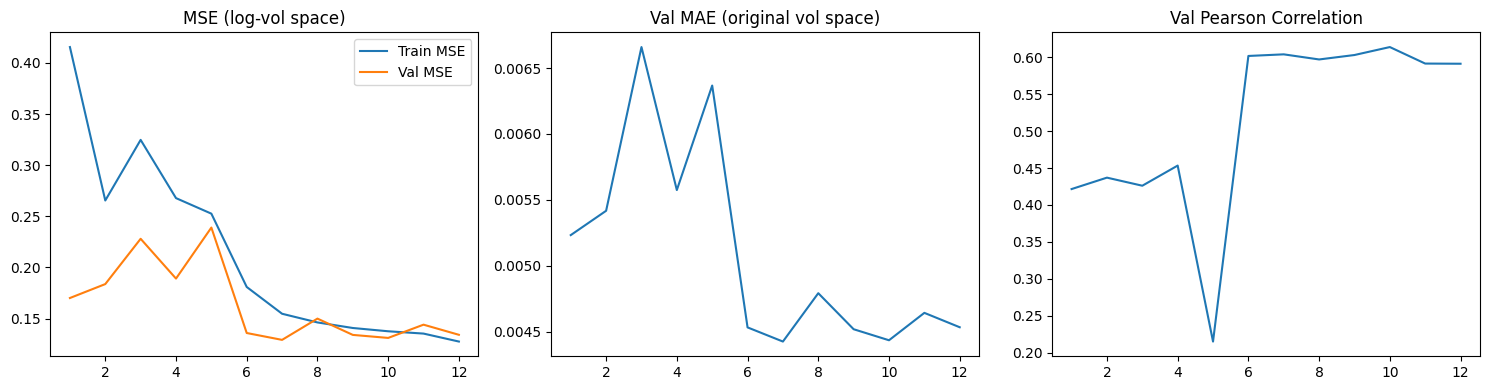

In [ ]:
epochs = range(1, len(history['train_mse']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history['train_mse'], label='Train MSE')
axes[0].plot(epochs, history['val_mse'],   label='Val MSE')
axes[0].set_title('MSE (log-vol space)'); axes[0].legend()

axes[1].plot(epochs, history['val_mae'])
axes[1].set_title('Val MAE (original vol space)')

axes[2].plot(epochs, history['val_corr'])
axes[2].set_title('Val Pearson Correlation')

plt.tight_layout()
plt.savefig(f'learning_curves_lookback{LOOKBACK}.png', dpi=150)
plt.show()

## 7. Test Set Evaluation (full 2019–2020)

In [ ]:
test_metrics = evaluate(model, test_loader, DEVICE)

print('=== Test Results ===')
print(f'  MSE (log-vol):        {test_metrics["mse"]:.5f}')
print(f'  MAE (original vol):   {test_metrics["mae"]:.5f}')
print(f'  Pearson Correlation:  {test_metrics["correlation"]:.4f}')
print("LOOKBACK:", LOOKBACK)
print("BATCH_SIZE:", BATCH_SIZE)
print("EMBED_DIM:", EMBED_DIM, "HIDDEN_SIZE:", HIDDEN_SIZE, "DROPOUT:", DROPOUT)
print("DEVICE:", DEVICE)
print("Trainable params:", total_params)
print("LR:", optimizer.param_groups[0]['lr'])
print("num_epochs", num_epochs)

=== Test Results ===
  MSE (log-vol):        0.22653
  MAE (original vol):   0.00731
  Pearson Correlation:  0.5702
LOOKBACK: 60
BATCH_SIZE: 256
EMBED_DIM: 64 HIDDEN_SIZE: 64 DROPOUT: 0.1
DEVICE: cuda
Trainable params: 14785
LR: 0.00025
num_epochs 50
